# Plotting

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
CM = 1 / 2.54

## Scalability

In [5]:
con_sca = pd.read_table("consensus_scalability.tsv", sep="\t").astype(
    {"consensus_method": "category"}
)

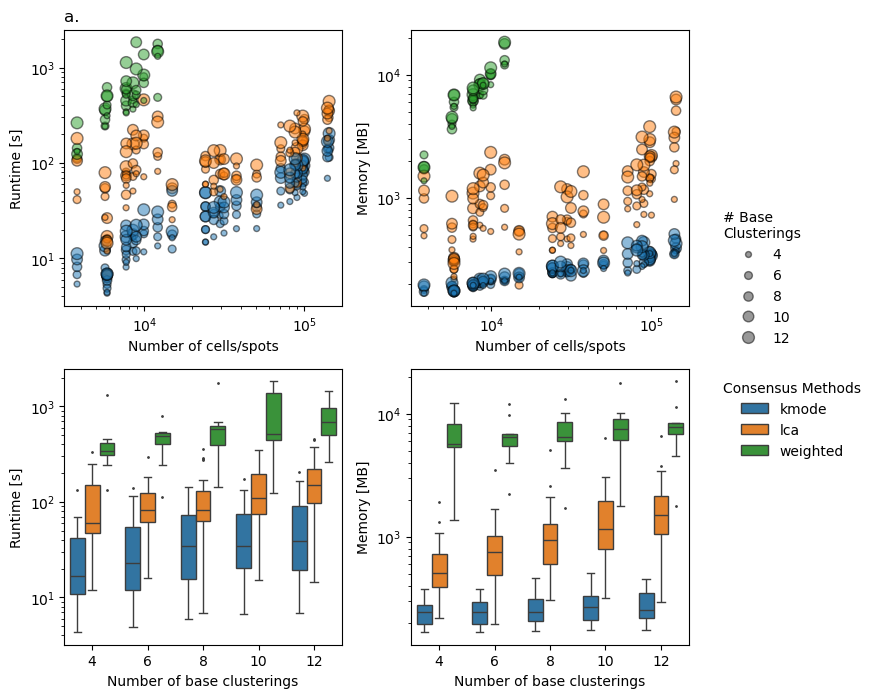

In [ ]:
%matplotlib inline
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18 * CM, 18 * CM), sharex="row")

label_time = "Runtime [s]"
label_memory = "Memory [MB]"
label_spots = "Number of cells/spots"
label_methods = "Number of base clusterings"

kwargs = dict(data=con_sca, hue="consensus_method")

# nr of observations
scatter_kwargs = dict(
    size="BC_number",
    lw=1,
    edgecolor="black",
    alpha=0.5,
)
x = "n_obs"

sns.scatterplot(x=x, y="runtime_s", ax=axs[0, 0], **kwargs, **scatter_kwargs)
axs[0, 0].set(xscale="log", xlabel=label_spots)
axs[0,0].set_title("a.", loc='left')

sns.scatterplot(x=x, y="memory_mb", ax=axs[0, 1], **kwargs, **scatter_kwargs)
axs[0, 1].set(xscale="log", xlabel=label_spots)
axs[0,1].set_title("b.", loc='left')

# nr of input clusterings
boxplot_kwargs = dict(
    flierprops={"marker": ".", "markerfacecolor": "black", "markersize": 2}
)

x = "BC_number"
size = "n_obs"
sns.boxplot(x=x, y="runtime_s", ax=axs[1, 0], **kwargs, **boxplot_kwargs)
axs[1, 0].set(xlabel=label_methods)
axs[1,0].set_title("c.", loc='left')

sns.boxplot(x=x, y="memory_mb", ax=axs[1, 1], **kwargs, **boxplot_kwargs)
axs[1, 1].set(xlabel=label_methods)
axs[1,1].set_title("d.", loc='left')

for ax in axs[:, 0]:
    ax.set(ylabel=label_time)

for ax in axs[:, 1]:
    ax.set(ylabel=label_memory)

for ax in axs.ravel():
    ax.set(yscale="log")
    ax.legend_.remove()

handles, labels = axs[1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Consensus Methods",
    loc="center left",
    bbox_to_anchor=(1.01, 0.4),
    frameon=False,
)
handles, labels = axs[0, 0].get_legend_handles_labels()
handles = handles[5:]
labels = labels[5:]
fig.legend(
    handles,
    labels,
    title="# Base\nClusterings",
    loc="center left",
    bbox_to_anchor=(1.01, 0.6),
    frameon=False,
)

fig.tight_layout()

fig.savefig("consensus_scalability.svg", bbox_inches="tight")
fig.savefig("consensus_scalability.png", dpi=300, bbox_inches="tight")

In [20]:
con_sca.n_obs.describe()

count       311.000000
mean      40188.038585
std       42131.451148
min        3798.000000
25%        7706.000000
50%       24125.000000
75%       81236.000000
max      142991.000000
Name: n_obs, dtype: float64

## Consensus for multiple datasets

In [24]:
from matplotlib.colors import Normalize


ref_cluster = "consensus_kmode"

consensus_files = Path(".").glob("label_con*.tsv")

s_dic = {
    "STARmap_plus": 15,
    "visium_breast_cancer_SEDR": 20,
    "abc_atlas_wmb_thalamus": 3,
    "xenium-mouse-brain-SergioSalas": 0.8,
    "stereoseq_liver": 4,
    "cosmx_lung": 1,
}

In [25]:
from scipy.optimize import linear_sum_assignment


def match_cluster(reference, cluster):
    contingency_table = pd.crosstab(cluster, reference)
    row_ind, col_ind = linear_sum_assignment(contingency_table, maximize=True)
    return cluster.cat.rename_categories(
        dict(zip(contingency_table.index[row_ind], contingency_table.columns[col_ind]))
    )

In [26]:
from matplotlib.colors import LinearSegmentedColormap

cme_cmap = LinearSegmentedColormap.from_list("gray_pink", ["#E5E5E5", "#8B0A50"])

In [ ]:
width = 16

for f in consensus_files:
    df = pd.read_table(f, sep="\t", index_col=0)

    consensus_clusters = [col for col in df.columns if col.startswith("consensus_")]
    base_clusters = [col for col in df.columns if col.endswith("_label")]

    df = df.astype({col: "category" for col in base_clusters + consensus_clusters})

    n_plots = len(base_clusters) + len(consensus_clusters) + 1
    n_cols = 3
    n_rows = -(n_plots // -n_cols)

    x, y = df[["x", "y"]].max() - df[["x", "y"]].min()
    aspect = x / y * 1.2
    height = width * (n_rows / n_cols) / aspect

    fig, axs = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(width, height),
        sharex=True,
        sharey=True,
    )

    axf = axs.ravel()

    dataset = df["data"].unique()[0]
    s = s_dic.get(dataset, 1)

    scatter_kwargs = dict(x="x", y="y", s=s, rasterized=True, legend=None, lw=0)

    for i, col in enumerate(base_clusters):
        if col != ref_cluster:
            df[col] = match_cluster(df[ref_cluster], df[col])

        sns.scatterplot(
            data=df,
            hue=col,
            ax=axf[i],
            hue_order=df[ref_cluster].cat.categories,
            **scatter_kwargs,
        )
        axf[i].set_title(f"Base Clustering:\n{col.replace('_label', '')}")

    for i, col in enumerate(consensus_clusters):
        i += len(base_clusters)
        if col != ref_cluster:
            df[col] = match_cluster(df[ref_cluster], df[col])

        sns.scatterplot(
            data=df,
            hue=col,
            ax=axf[i],
            hue_order=df[ref_cluster].cat.categories,
            **scatter_kwargs,
        )
        axf[i].set_title(col, color='blue')


    norm = Normalize(
        vmin=df["cross_method_entropy"].min(), vmax=df["cross_method_entropy"].max()
    )
    ax = axf[i + 1]
    sc = sns.scatterplot(
        data=df,
        hue="cross_method_entropy",
        ax=ax,
        hue_norm=norm,
        palette=cme_cmap,
        **scatter_kwargs,
    )
    ax.set_title("cross_method_entropy", color="blue")
    sc.collections[0].set_cmap(cme_cmap)
    sc.collections[0].set_clim(
        df["cross_method_entropy"].min(), df["cross_method_entropy"].max()
    )
    cbar = fig.colorbar(sc.collections[0], ax=ax, label="CME")
    # cbar.set_label("CME")

    for ax in axf:
        ax.set_aspect("equal", adjustable="box")
        ax.axis("off")

    fig.suptitle(f"Consensus without experts:{dataset}", y=1.02, fontsize=16)
    fig.tight_layout()
    fig.savefig(f"{dataset}_consensus.png", dpi=300, bbox_inches="tight")
    #fig.savefig(f"{dataset}_consensus.svg", dpi=300, bbox_inches="tight")